# Hypothesis Testing
    Hypothesis Testing is a statistical method used to determine whether there is enough evidence from a sample to support a claim about a population.

    Instead of making decisions based only on sample data, Hypothesis Testing helps determine whether the observed result is statistically significant or simply due to random chance.


### What Does Hypothesis Testing Do?

    Hypothesis Testing compares
        - the expected population value, and
        - the observed sample value.

    It then determines whether the observed difference is large enough to reject the original claim.

    The final conclusion is based on probability rather than personal opinion.

In [11]:
import numpy as np
import pandas as pd

import seaborn as sns

import matplotlib.pyplot as plt

from scipy.stats import norm



In [3]:


np.random.seed(42)

Employees = pd.DataFrame({

    "Employee_ID": range(1,501),

    "Monthly_Salary": np.random.normal(

        loc=60000,

        scale=8000,

        size=500

    )

})

Employees.head()

,Employee_ID,Monthly_Salary
0,1,63973.713224
1,2,58893.885591
2,3,65181.508305
3,4,72184.238851
4,5,58126.773002


In [4]:
sample = Employees.sample( n=50,random_state=42 )

sample.head()

,Employee_ID,Monthly_Salary
361,362,72261.911304
73,74,72517.149247
374,375,77225.459660
155,156,54285.188656
104,105,58709.714307


In [6]:
population_mean = Employees['Monthly_Salary'].mean()

sample_mean = sample["Monthly_Salary"].mean()

print(f"Claimed Population Mean : {population_mean:.2f}")

print(f"Sample Mean : {sample_mean:.2f}")

Claimed Population Mean : 60054.70
Sample Mean : 61630.69


### Key points
    - Hypothesis Testing is used to evaluate claims about a population.
    - It uses sample data to make statistical decisions.
    - It helps distinguish between real differences and random variation.
    - Business decisions should be based on statistical evidence rather than assumptions.

## Null Hypothesis (H₀)
    The Null Hypothesis, denoted by H₀, represents the default assumption.

    It states that there is no significant difference, no effect, or no relationship in the population.

    The Null Hypothesis is assumed to be true unless the sample provides strong evidence against it.

    In Hypothesis Testing, our goal is not to prove the Null Hypothesis.


## Alternative Hypothesis (H₁)
    The Alternative Hypothesis, denoted by H₁ or Ha, represents the claim that we want to investigate.

    It states that a significant difference, effect, or relationship exists in the population.

    The Alternative Hypothesis is accepted only if there is sufficient statistical evidence against the Null Hypothesis.

### Types of Alternative Hypotheses
    There are three types of hypothesis tests.
        1. Two-tailed Test
        2. Left-tailed Test
        3. Right-tailed Test


### Two-Tailed Test

    A Two-Tailed Test checks whether the population parameter is different from the claimed value.

    Either an increase or a decrease is considered important.

    The hypotheses are

$$
H_0:\mu=\mu_0
$$

$$
H_1:\mu\neq\mu_0
$$

    Example
        A company claims that the average salary is ₹60,000.

        The analyst wants to determine whether the true average salary is different.

        Both higher and lower values are important.

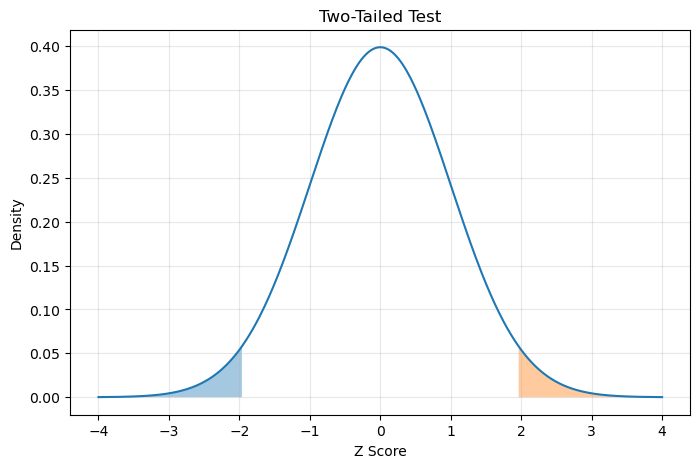

In [12]:
x = np.linspace(-4,4,500)
y = norm.pdf(x)

plt.figure(figsize=(8,5))

plt.plot(x,y)

plt.fill_between(x,y,where=(x<=-1.96),alpha=0.4)

plt.fill_between(x,y,where=(x>=1.96),alpha=0.4)

plt.title("Two-Tailed Test")

plt.xlabel("Z Score")

plt.ylabel("Density")

plt.grid(alpha=0.3)

plt.show()

### Left-Tailed Test
    A Left-Tailed Test checks whether the population parameter is smaller than the claimed value.

    The hypotheses are

$$
H_0:\mu\ge\mu_0
$$

$$
H_1:\mu<\mu_0
$$

    Example
    A factory claims that the average lifetime of a battery is at least 10 hours.

    The quality engineer wants to determine whether the lifetime has decreased.

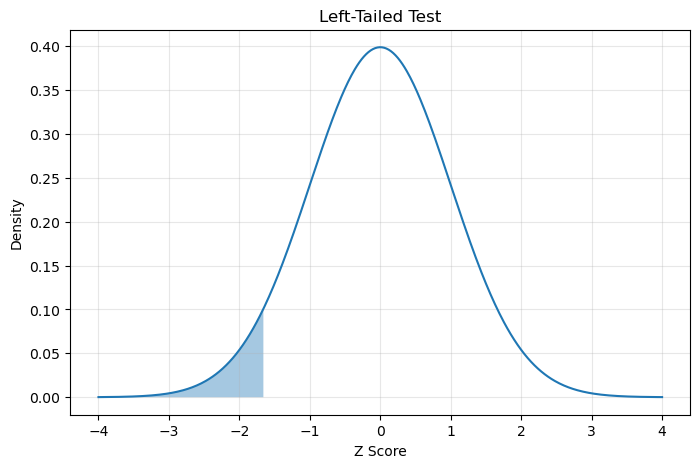

In [13]:
plt.figure(figsize=(8,5))

plt.plot(x,y)

plt.fill_between(x,y,where=(x<=-1.645),alpha=0.4)

plt.title("Left-Tailed Test")

plt.xlabel("Z Score")

plt.ylabel("Density")

plt.grid(alpha=0.3)

plt.show()

### Right-Tailed Test
    A Right-Tailed Test checks whether the population parameter is greater than the claimed value.

    The hypotheses are

$$
H_0:\mu\le\mu_0
$$

$$
H_1:\mu>\mu_0
$$

    Example
    An online shopping company launches a new recommendation system.

    The analyst wants to determine whether the average customer purchase amount has increased.

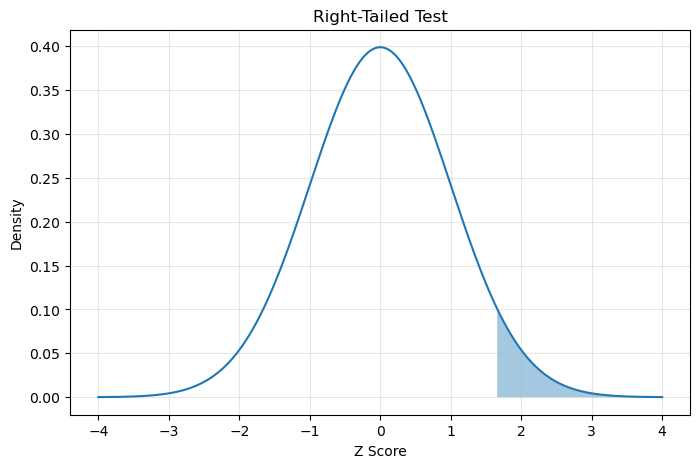

In [14]:
plt.figure(figsize=(8,5))

plt.plot(x,y)

plt.fill_between(x,y,where=(x>=1.645),alpha=0.4)

plt.title("Right-Tailed Test")

plt.xlabel("Z Score")

plt.ylabel("Density")

plt.grid(alpha=0.3)

plt.show()

### Significance Level (α)
    The Significance Level, denoted by α (alpha), is the maximum probability of rejecting a true Null Hypothesis.

    It represents the acceptable level of risk for making an incorrect decision.

    The most commonly used significance level is

$$
\alpha = 0.05
$$

    which means we accept a 5% chance of making a Type I Error.

### Common Significance Levels

| Confidence Level | Significance Level (α) |
|------------------|------------------------|
| 90% | 0.10 |
| 95% | 0.05 |
| 99% | 0.01 |

### Statistical Decision Rule
    The decision is based on comparing the p-value with the Significance Level.

                                                        If
$$
p \le \alpha
$$

                                                        Reject the Null Hypothesis.

                                                        If

$$
p > \alpha
$$

                                                        Fail to Reject the Null Hypothesis.

### Type I Error
    A Type I Error occurs when we reject a true Null Hypothesis.

    It is also called a False Positive.

    The probability of a Type I Error is equal to the Significance Level.

$$
P(Type\ I\ Error)=\alpha
$$

    Suppose a bank believes a new fraud detection system is better than the old one.

    After testing,
        the analyst concludes that the new system is better.

    However,
        the new system is actually not better.

    This incorrect decision is a Type I Error.

### Type II Error
    A Type II Error occurs when we fail to reject a false Null Hypothesis.

    It is also called a False Negative.
    The probability of a Type II Error is denoted by

$$
\beta(Bita)
$$

    Suppose a hospital tests a new medicine.
        The medicine actually works better than the current treatment.

    However,
        the statistical test concludes that there is no improvement.

    This incorrect decision is a Type II Error.

### Comparison of Type I and Type II Errors

| Error Type | Decision | Reality |
|------------|----------|----------|
| Type I Error | Reject \(H_0\) | \(H_0\) is actually true |
| Type II Error | Fail to Reject \(H_0\) | \(H_0\) is actually false |

###  Example
    A company claims that the average monthly salary of its employees is ₹60,000.

    An HR analyst collects a random sample of employees to verify this claim.

    The sample average salary is ₹58,500.

    The analyst wants to determine whether this difference is statistically significant.


In [24]:
claimed_mean = 60000

sample_mean = 58500

alpha = 0.05

population_std=8000

sample_size=50

print(f"Claimed Mean : ₹{claimed_mean:,.0f}")

print(f"Sample Mean  : ₹{sample_mean:,.0f}")

print(f"Population STD : {population_std:,.0f}")

print(f"Sample Size : {sample_size:,.0f}")

print(f"Significance Level (α) : {alpha}")

Claimed Mean : ₹60,000
Sample Mean  : ₹58,500
Population STD : 8,000
Sample Size : 50
Significance Level (α) : 0.05


### Define the Hypotheses
    Since the analyst wants to determine whether the average salary is different from ₹60,000,

    the hypotheses are

$$
H_0:\mu=60000
$$

$$
H_1:\mu\neq60000
$$

    This is a Two-Tailed Test.

In [19]:
print("Null Hypothesis (H₀): μ = 60000")

print("Alternative Hypothesis (H₁): μ ≠ 60000")

print("Test Type : Two-Tailed")

Null Hypothesis (H₀): μ = 60000
Alternative Hypothesis (H₁): μ ≠ 60000
Test Type : Two-Tailed


### Select the Significance Level

    The analyst selects

$$
\alpha=0.05
$$

    This means the analyst is willing to accept a 5% probability of making a Type I Error.

In [20]:
confidence_level = 1 - alpha

print(f"Confidence Level : {confidence_level:.0%}")

print(f"Significance Level : {alpha:.0%}")

Confidence Level : 95%
Significance Level : 5%


### Calculate the Standard Error
    Formula

$$
SE=\frac{\sigma}{\sqrt{n}}
$$

In [25]:
SE = population_std / np.sqrt(sample_size)

print(SE)

1131.370849898476


### Calculate the Z-Test Statistic

    Formula

$$
Z=\frac{\bar{x}-\mu}{\sigma/\sqrt{n}}
$$

In [26]:
z = (sample_mean - population_mean) / SE

print(z)

-1.3741771381582768


###  Calculate the p-value

In [28]:
p_value = 2 * norm.cdf(z)

print(p_value)

0.16938669640349213


### Make The Decision
    Decision Rule 

    If

$$
p \le \alpha
$$

        Reject the Null Hypothesis.

    Otherwise,
        Fail to Reject the Null Hypothesis.


In [36]:
print(f'P_Value:({p_value}) < Alpha ({alpha})')



P_Value:(0.16938669640349213) < Alpha (0.05)


In [29]:
if p_value <= alpha:

    print("Reject the Null Hypothesis")

else:

    print("Fail to Reject the Null Hypothesis")

Fail to Reject the Null Hypothesis


### Step 8: Interpretation

    The sample mean salary is ₹58,500.

    Although it is lower than the claimed average salary of ₹60,000,

    the difference is not statistically significant at the 5% significance level.

    Therefore,

    there is insufficient statistical evidence to conclude that the company's claim is incorrect.

    The analyst fails to reject the Null Hypothesis.